In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from src.arms import UniformArm
from src.instance import BanditInstance
from src.algorithms import UniformPolicy, SimpleMirrorAscent
from src.runner import run_single_experiment

In [4]:
rng = np.random.default_rng(123)

arms = [
    UniformArm(0.0, 1.0),
    UniformArm(0.2, 0.8),
    UniformArm(-0.5, 1.0),
]

instance = BanditInstance(arms, name="toy_uniform_instance")
utility = VarianceUtility()

print(instance)
print("means =", instance.means())
print("second moments =", instance.second_moments())
print("variances =", instance.variances())

w = np.array([0.2, 0.3, 0.5])
print("U(w) =", utility.value(instance, w))
print("grad U(w) =", utility.gradient(instance, w))
print("Hessian =\n", utility.hessian(instance))

BanditInstance(name='toy_uniform_instance', K=3)
means = [0.5  0.5  0.25]
second moments = [0.33333333 0.28       0.25      ]
variances = [0.08333333 0.03       0.1875    ]
U(w) = 0.13504166666666667
grad U(w) = [-0.04166667 -0.095       0.0625    ]
Hessian =
 [[-0.5   -0.5   -0.25 ]
 [-0.5   -0.5   -0.25 ]
 [-0.25  -0.25  -0.125]]


In [5]:
for k in range(instance.K):
    samples = np.array([instance.sample(k, rng) for _ in range(5000)])
    print(f"arm {k}: empirical mean = {samples.mean():.4f}, empirical var = {samples.var():.4f}")

arm 0: empirical mean = 0.4961, empirical var = 0.0809
arm 1: empirical mean = 0.4956, empirical var = 0.0295
arm 2: empirical mean = 0.2491, empirical var = 0.1875


In [7]:
rng = np.random.default_rng(123)

arms = [
    UniformArm(0.0, 1.0),
    UniformArm(0.2, 0.8),
    UniformArm(-0.5, 1.0),
]

instance = BanditInstance(arms, name="toy_uniform_instance")
utility = VarianceUtility()

alg = SimpleMirrorAscent(K=instance.K, eta=0.2)
alg.reset(rng)

T = 200
weights_history = []

for t in range(T):
    a = alg.select_action()
    r = instance.sample(a, rng)
    alg.update(a, r)
    weights_history.append(alg.current_weights())

weights_history = np.array(weights_history)
weights_history[:5]

array([[0.34251669, 0.34251669, 0.31496663],
       [0.35075745, 0.33805905, 0.3111835 ],
       [0.38759103, 0.31821267, 0.2941963 ],
       [0.3898531 , 0.31969194, 0.29045496],
       [0.3669926 , 0.30449181, 0.32851559]])

Matplotlib is building the font cache; this may take a moment.


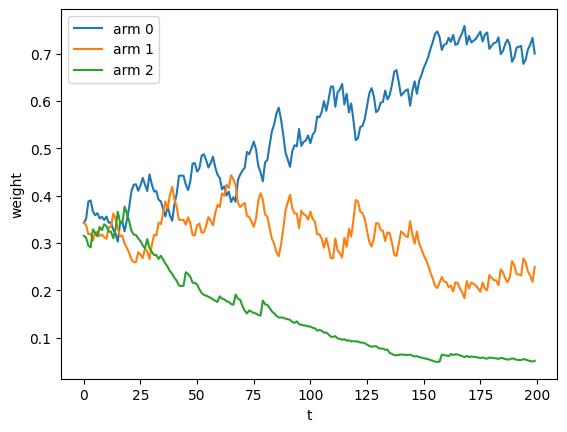

In [ ]:
for k in range(instance.K):
    plt.plot(weights_history[:, k], label=f"arm {k}")

plt.xlabel("t")
plt.ylabel("weight")
plt.legend()
plt.show()

In [10]:
arms = [
    UniformArm(0.0, 1.0),
    UniformArm(0.2, 0.8),
    UniformArm(-0.5, 1.0),
]

instance = BanditInstance(arms, name="toy_uniform_instance")
alg = SimpleMirrorAscent(K=instance.K, eta=0.2)

results = run_single_experiment(instance, alg, T=200, seed=123)

print(results["instance_name"])
print(results["algorithm_name"])
print(results["actions"][:10])
print(results["rewards"][:10])
print(results["weights"].shape)

toy_uniform_instance
simple_mirror_ascent
[2 0 0 2 2 1 2 2 2 2]
[-0.41926847  0.18437181  0.81209451 -0.0851384   0.83483904  0.34697876
 -0.17935555  0.44491031 -0.15213772  0.27724756]
(200, 3)


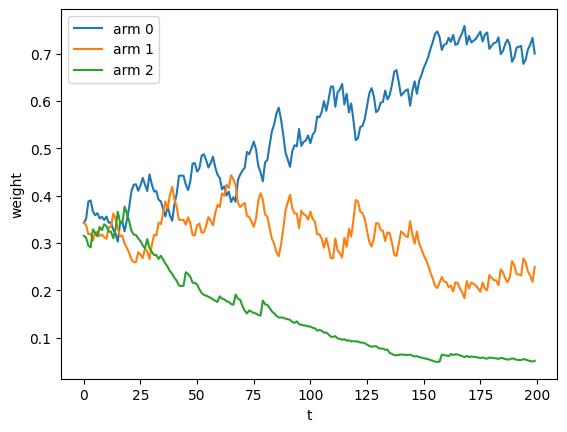

In [11]:
weights = results["weights"]

for k in range(weights.shape[1]):
    plt.plot(weights[:, k], label=f"arm {k}")

plt.xlabel("t")
plt.ylabel("weight")
plt.legend()
plt.show()

In [12]:
from src.runner import save_results_npz, save_metadata_json

save_results_npz(results, "G:\\Mi unidad\\projects\\distributional-bandits\\distributional-bandits\\results\\raw\\test_run.npz")
save_metadata_json(results, "G:\\Mi unidad\\projects\\distributional-bandits\\distributional-bandits\\results\\raw\\test_run.json")